
# Online HMM-AR(1) Expectation-Maximization

This notebook implements an **online Expectation-Maximization algorithm** for an autoregressive Hidden Markov Model of order 1, HMM-AR(1).

The implementation is inspired by the methodology proposed in Fanelli, Fontana and Rotondi (2023), *A hidden Markov model for statistical arbitrage in international crude oil futures markets*. The model is designed to estimate, in an online fashion, the parameters of a regime-switching autoregressive process in which the observed time series follows different AR(1) dynamics depending on an unobserved Markov state.

The observed process is defined as:

$$
S_t =
\gamma_{X_{t-1}}
+
\alpha_{X_{t-1}} S_{t-1}
+
\eta_{X_{t-1}} \varepsilon_t,
\qquad
\varepsilon_t \sim \mathcal{N}(0,1),
$$

where:

$$
\mathbb{P}(X_t = j \mid X_{t-1} = i) = p_{ij},
\qquad
P = \left(p_{ij}\right)_{i,j=1}^{N}.
$$

Here, $(S_t)$ denotes the observed time series, while $(X_t)$ is a latent Markov chain taking values in a finite set of hidden regimes. Each regime is characterized by its own intercept $(\gamma_i)$, autoregressive coefficient $(\alpha_i)$, and innovation volatility $(\eta_i)$.

The notebook includes:

- an implementation of the online filtering step;
- recursive updates of the sufficient statistics used by the EM algorithm;
- parameter updates for the transition matrix and the regime-dependent AR(1) coefficients;
- numerical safeguards against underflow and instability;
- a one-step-ahead forecasting function;
- a simulation study to test whether the algorithm is able to recover the true parameters of a synthetic HMM-AR(1) process.

The goal of this notebook is primarily educational and experimental. It provides a Python implementation of the online HMM-AR(1) estimation procedure and tests its behaviour on simulated data before applying it to financial time series or statistical arbitrage applications.

This notebook is not intended as financial advice and the trading strategy component should be considered only as a research prototype.

## Reference

\begin{aligned}
&\text{Fanelli, V., Fontana, C., and Rotondi, F. (2023).} \\
&\textit{A hidden Markov model for statistical arbitrage in international crude oil futures markets.} \\
&\text{arXiv preprint arXiv:2309.00875.}
\end{aligned}




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class OnlineARHMMEM:
    """
    Online / filter-based EM per un AR(1)-HMM:

        S_t = gamma[X_{t-1}] + alpha[X_{t-1}] * S_{t-1}
              + eta[X_{t-1}] * eps_t

        P[i, j] = Prob(X_t = j | X_{t-1} = i)
    """

    def __init__(
        self,
        S: np.ndarray,
        n_regimes: int = 2,
        P0: np.ndarray | None = None,
        gamma0: np.ndarray | None = None,
        alpha0: np.ndarray | None = None,
        eta0: np.ndarray | None = None,
        x0: np.ndarray | None = None,
        init_points: int = 20,
        batch_size: int = 10,
        mstep: str = "paper",
        min_eta: float = 1e-6,
        eps: float = 1e-12,
        enforce_stationarity: bool = True,
    ):
        """
        :param init_point: how many data-points to use to estimate the starting ols params for gamma alpha and eta, first 20 datapoints are used
                           by default.
        :param min_eta:    minmum value of the standard deviation parameter in both states. this protects from overlow and underflow during the 
                           estimation process
        :param eps:        general lower bound value to protect from other overflow7underflow problems
        """
        self.S = np.asarray(S, dtype=float).reshape(-1)
        if len(self.S) < 3:
            raise ValueError("You need at least 3 observations of the process.")

        self.N = n_regimes
        self.batch_size = batch_size
        self.mstep = mstep
        self.min_eta = min_eta #lower bound to the variance terms in the two states to reduce underflow problems
        self.eps = eps
        self.enforce_stationarity = enforce_stationarity

        #Starting pint X0 hat as reported in the paper
        #if None set in to e1 as in the paper
        if x0 is None:
            self.p = np.zeros(self.N)
            self.p[0] = 1.0
        else:
            self.p = np.asarray(x0, dtype=float).reshape(-1)
            self.p = self.p / self.p.sum()

        
        # Inital estimates of the parameters as reported in the paper
        g_ols, a_ols, e_ols = self._ols_initial_estimates(init_points)

        if P0 is None:
            if self.N == 2:
                # setting inital probs in the 2 states case as reported in the paper: pi_11=0.6, pi_22=0.5
                self.P = np.array(
                    [
                        [0.60, 0.40],
                        [0.50, 0.50],
                    ],
                    dtype=float,
                )
            else:
                #if more than 2 hidden states
                self.P = np.full((self.N, self.N), 1.0 / self.N)
                np.fill_diagonal(self.P, 0.70)
                #normalize to 1
                self.P = self.P / self.P.sum(axis=1, keepdims=True)
        else:
            self.P = np.asarray(P0, dtype=float)
            #normalize to 1 to be just to be sure
            self.P = self.P / self.P.sum(axis=1, keepdims=True)

        #as reported in the paper the initial estimates are scaled for the starting parametrization by factors: 1.3 and 0.7
        if gamma0 is None:
            if self.N == 2:          
                self.gamma = np.array([1.3 * g_ols, 0.7 * g_ols])
            elif self.N == 3:
                self.gamma = np.array([1.3 * g_ols, g_ols, 0.7 * g_ols])
            else:
                self.gamma = np.full(self.N, g_ols)
        else:
            self.gamma = np.asarray(gamma0, dtype=float).reshape(-1)

        if alpha0 is None:
            if self.N == 2:
                self.alpha = np.array([1.3 * a_ols, 0.7 * a_ols])
            elif self.N == 3:
                self.alpha = np.array([1.3 * a_ols, a_ols, 0.7 * a_ols])
            else:
                self.alpha = np.full(self.N, a_ols)
        else:
            self.alpha = np.asarray(alpha0, dtype=float).reshape(-1)

        if eta0 is None:
            if self.N == 2:
                self.eta = np.array([1.3 * e_ols, 0.7 * e_ols])
            elif self.N == 3:
                self.eta = np.array([1.3 * e_ols, e_ols, 0.7 * e_ols])
            else:
                self.eta = np.full(self.N, e_ols)
        else:
            self.eta = np.asarray(eta0, dtype=float).reshape(-1)

        self.eta = np.maximum(self.eta, self.min_eta)

        #check on alpha to guarantee that the process is initialized in a point where the HMM AR1 i stationary
        if self.enforce_stationarity:
            self.alpha = np.clip(self.alpha, -0.999, 0.999)

        # ----------------------------
        # Recursive sufficient statistics
        # ----------------------------
        #
        # rho_occ = O hat of the paper represent the conditioned expected occupation time in the different states
        # conditional on current state X_t = j and observations up to t.
        #
        # rho_x = T(St-1) of the paper contains the expected sum of the process lagged at time t given that in t we are in state j
        # rho_x = T(St) of the paper contains the expected sum of the process at time t given that in t we are in state j
        # rho_xx = T(St-1 ** 2) of the paper contains the expected sum of the lagged process squared at time t given that in t we are in state j
        # rho_yy = T(St ** 2) of the paper contains the expected sum of the process squared at time t given that in t we are in state j
        # rho_yy = T(St * St-1) of the paper contains the expected sum of the process product at time t given that in t we are in state j
        # rho_J = J hat of the paper contains the expected cumulative sum of jumps from one state to the other at time t given that in t we are in 
        #         state j
        # all this alements will be updated in each of the estimation steps

        self.rho_occ = np.zeros((self.N, self.N))
        self.rho_x = np.zeros((self.N, self.N))
        self.rho_y = np.zeros((self.N, self.N))
        self.rho_xx = np.zeros((self.N, self.N))
        self.rho_xy = np.zeros((self.N, self.N))
        self.rho_yy = np.zeros((self.N, self.N))

        self.rho_J = np.zeros((self.N, self.N, self.N))

        #itialize the loglikelhood and the estimation history
        self.loglik = 0.0
        self.history = []

    # ============================================================
    # INITIAL OLS
    # ============================================================
    #this function is usefull to reduce overflow problems
    @staticmethod
    def _logsumexp(a: np.ndarray):
        a = np.asarray(a, dtype=float)
        m = np.max(a)

        if not np.isfinite(m):
            return -np.inf

        return m + np.log(np.sum(np.exp(a - m)))

    def _ols_initial_estimates(self, init_points: int)->[float, float, float]:
        """
        this funtion estimate the ols parameters on the first observations to initialize
        the vectors eta0, alpha0 and gamma0 if not provided by the user and according to
        the desctiption of the paper.
        """
        m = min(init_points, len(self.S) - 1)

        x = self.S[:m]
        y = self.S[1 : m + 1]

        Xmat = np.column_stack([np.ones_like(x), x])
        beta, *_ = np.linalg.lstsq(Xmat, y, rcond=None)

        gamma_ols = beta[0]
        alpha_ols = beta[1]

        resid = y - Xmat @ beta
        eta_ols = np.std(resid, ddof=2)

        if not np.isfinite(eta_ols) or eta_ols <= 0:
            eta_ols = np.std(y, ddof=1)

        eta_ols = max(float(eta_ols), self.min_eta)

        return float(gamma_ols), float(alpha_ols), eta_ols

    # ============================================================
    # DENSITY / FILTER STEP
    # ============================================================

    def _emission_loglikelihood(self, x: float, y: float)->np.ndarray:
        """
        this function compute:
        log f(y | x, regime=i)
        with y = S_t, x = S_{t-1}
        """
        mu = self.gamma + self.alpha * x
        sigma = np.maximum(self.eta, self.min_eta) #lb to protect for underflow

        z = (y - mu) / sigma

        log_like = -0.5 * np.log(2.0 * np.pi) - np.log(sigma) - 0.5 * z**2

        return log_like

    def step(self, n: int, update_params: bool = True):
        """
        Upddate the parameters on time for observation index n in the process ndarray

            x = S[n-1]
            y = S[n]

        firs valid step: n=1.
        """

        if n <= 0:
            raise ValueError("n needs to be >= 1 since S[n-1], S[n] are needed in the computation.")

        x = self.S[n - 1]
        y = self.S[n]

        p_old = self.p.copy()

        rho_occ_old = self.rho_occ.copy()
        rho_x_old = self.rho_x.copy()
        rho_y_old = self.rho_y.copy()
        rho_xx_old = self.rho_xx.copy()
        rho_xy_old = self.rho_xy.copy()
        rho_yy_old = self.rho_yy.copy()
        rho_J_old = self.rho_J.copy()

        log_like = self._emission_loglikelihood(x, y)

        log_p_old = np.log(np.maximum(p_old, self.eps))
        log_P = np.log(np.maximum(self.P, self.eps))

        # log joint:
        # log P(X_{n-1}=i | data)
        # + log P(X_n=j | X_{n-1}=i)
        # + log f(S_n | S_{n-1}, X_{n-1}=i)
        log_joint = log_p_old[:, None] + log_P + log_like[:, None]
        #from vector to scalar protected form overlow
        log_norm = self._logsumexp(log_joint)

        if not np.isfinite(log_norm):
            print("DEBUG FILTER FAILURE")
            print("n:", n)
            print("x=S[n-1]:", x)
            print("y=S[n]:", y)
            print("p_old:", p_old)
            print("P:", self.P)
            print("gamma:", self.gamma)
            print("alpha:", self.alpha)
            print("eta:", self.eta)
            print("log_like:", log_like)
            raise FloatingPointError("log_norm non finito nel filtro.")

        xi = np.exp(log_joint - log_norm)

        xi = np.maximum(xi, 0.0)
        xi = xi / xi.sum()

        p_new = xi.sum(axis=0)
        p_new = np.maximum(p_new, self.eps)
        p_new = p_new / p_new.sum()

        self.loglik += log_norm

        # ------------------------------------------------------------
        # Recoursive adjustment of the sufficient statistics
        # ------------------------------------------------------------

        rho_occ_new = np.zeros_like(self.rho_occ)
        rho_x_new = np.zeros_like(self.rho_x)
        rho_y_new = np.zeros_like(self.rho_y)
        rho_xx_new = np.zeros_like(self.rho_xx)
        rho_xy_new = np.zeros_like(self.rho_xy)
        rho_yy_new = np.zeros_like(self.rho_yy)
        rho_J_new = np.zeros_like(self.rho_J)

        for j in range(self.N):
            if p_new[j] <= self.eps:
                continue

            # weights[i] = P(X_{n-1}=i | X_n=j, time n)
            #wheights starting from arriving to j
            weights = xi[:, j] / p_new[j]

            for i in range(self.N):
                w = weights[i]

                h_occ = np.zeros(self.N)
                h_x = np.zeros(self.N)
                h_y = np.zeros(self.N)
                h_xx = np.zeros(self.N)
                h_xy = np.zeros(self.N)
                h_yy = np.zeros(self.N)

                # starting regime is X_{n-1}=i
                h_occ[i] = 1.0
                h_x[i] = x
                h_y[i] = y
                h_xx[i] = x * x
                h_xy[i] = x * y
                h_yy[i] = y * y

                h_J = np.zeros((self.N, self.N))
                h_J[i, j] = 1.0

                rho_occ_new[j] += w * (rho_occ_old[i] + h_occ)
                rho_x_new[j] += w * (rho_x_old[i] + h_x)
                rho_y_new[j] += w * (rho_y_old[i] + h_y)
                rho_xx_new[j] += w * (rho_xx_old[i] + h_xx)
                rho_xy_new[j] += w * (rho_xy_old[i] + h_xy)
                rho_yy_new[j] += w * (rho_yy_old[i] + h_yy)

                rho_J_new[j] += w * (rho_J_old[i] + h_J)

        self.p = p_new

        self.rho_occ = rho_occ_new
        self.rho_x = rho_x_new
        self.rho_y = rho_y_new
        self.rho_xx = rho_xx_new
        self.rho_xy = rho_xy_new
        self.rho_yy = rho_yy_new
        self.rho_J = rho_J_new

        if update_params and n % self.batch_size == 0:
            self._m_step()

        self.history.append(
            {
                "n": n,
                "S_prev": x,
                "S_curr": y,
                "loglik": self.loglik,
                "p0": self.p[0],
                "p1": self.p[1] if self.N > 1 else np.nan,
                "gamma0": self.gamma[0],
                "gamma1": self.gamma[1] if self.N > 1 else np.nan,
                "alpha0": self.alpha[0],
                "alpha1": self.alpha[1] if self.N > 1 else np.nan,
                "eta0": self.eta[0],
                "eta1": self.eta[1] if self.N > 1 else np.nan,
                "P00": self.P[0, 0],
                "P11": self.P[1, 1] if self.N > 1 else np.nan,
            }
        )

    # ============================================================
    # TOTAL EXPECTED STATS
    # ============================================================

    def _totals(self)->dict:
        """
        Trasforma rho condizionate sullo stato corrente in statistiche totali:

            stat = sum_j p[j] * rho[j]
        """

        weights = self.p

        occ = np.tensordot(weights, self.rho_occ, axes=(0, 0))
        x = np.tensordot(weights, self.rho_x, axes=(0, 0))
        y = np.tensordot(weights, self.rho_y, axes=(0, 0))
        xx = np.tensordot(weights, self.rho_xx, axes=(0, 0))
        xy = np.tensordot(weights, self.rho_xy, axes=(0, 0))
        yy = np.tensordot(weights, self.rho_yy, axes=(0, 0))

        J = np.tensordot(weights, self.rho_J, axes=(0, 0))

        return {
            "occ": occ,
            "x": x,
            "y": y,
            "xx": xx,
            "xy": xy,
            "yy": yy,
            "J": J,
        }

    # ============================================================
    # M-STEP
    # ============================================================

    def _m_step(self):
        """
        this function updates the parameters as prescribed by the paper if self.mstep == "paper", or by Weighted OLS if self.mstep == "ols" 
        """
        st = self._totals()

        occ = st["occ"]
        Tx = st["x"]
        Ty = st["y"]
        Txx = st["xx"]
        Txy = st["xy"]
        Tyy = st["yy"]
        J = st["J"]

        gamma_new = self.gamma.copy()
        alpha_new = self.alpha.copy()
        eta_new = self.eta.copy()
        P_new = self.P.copy()

        # ----------------------------
        # Update transition matrix
        # ----------------------------
        for i in range(self.N):
            row_sum = J[i, :].sum()
            if row_sum > self.eps:
                P_new[i, :] = J[i, :] / row_sum

        # sicurezza numerica
        P_new = np.maximum(P_new, self.eps)
        P_new = P_new / P_new.sum(axis=1, keepdims=True)

        # ----------------------------
        # Update AR parameters
        # ----------------------------
        for i in range(self.N):
            if occ[i] <= self.eps:
                continue

            if self.mstep == "paper":
                gamma_i = (Ty[i] - self.alpha[i] * Tx[i]) / occ[i]

                if Txx[i] > self.eps:
                    alpha_i = (Txy[i] - gamma_i * Tx[i]) / Txx[i]
                else:
                    alpha_i = self.alpha[i]

            elif self.mstep == "ols":
                denom = occ[i] * Txx[i] - Tx[i] ** 2

                if abs(denom) > self.eps:
                    alpha_i = (occ[i] * Txy[i] - Tx[i] * Ty[i]) / denom
                    gamma_i = (Ty[i] - alpha_i * Tx[i]) / occ[i]
                else:
                    gamma_i = self.gamma[i]
                    alpha_i = self.alpha[i]

            else:
                raise ValueError("mstep needs to be 'paper' or 'ols'.")

            if self.enforce_stationarity:
                alpha_i = np.clip(alpha_i, -0.999, 0.999)

            eta2_i = (
                Tyy[i]
                - 2.0 * gamma_i * Ty[i]
                - 2.0 * alpha_i * Txy[i]
                + gamma_i**2 * occ[i]
                + 2.0 * alpha_i * gamma_i * Tx[i]
                + alpha_i**2 * Txx[i]
            ) / occ[i]

            if np.isfinite(eta2_i) and eta2_i > self.min_eta**2:
                eta_i = np.sqrt(eta2_i)
            else:
                eta_i = self.eta[i]

            gamma_new[i] = gamma_i
            alpha_new[i] = alpha_i
            eta_new[i] = max(eta_i, self.min_eta)

        self.P = P_new
        self.gamma = gamma_new
        self.alpha = alpha_new
        self.eta = eta_new

    # ============================================================
    #                      FIT / FORECAST
    # ============================================================

    def fit(self, update_params: bool = True)->pd.DataFrame:
        """
        Calculates the updates from n=1 to n=T.
        Using:
            (S_0, S_1), (S_1, S_2), ..., (S_{T-1}, S_T)
        """
        for n in range(1, len(self.S)):
            self.step(n, update_params=update_params)

        return pd.DataFrame(self.history)

    def one_step_forecast(self, S_t: float | None = None)->[float,float]:
        """
        This function calculates the mean and variance of the process conditioned to the parameters calculated at a specific time n
        This funtion is useful for the compuation of the probl stategy of the paper
        """
        if S_t is None:
            S_t = self.S[-1]

        mu_i = self.gamma + self.alpha * S_t

        mean = float(np.dot(self.p, mu_i))

        second_moment = np.dot(self.p, self.eta**2 + mu_i**2)
        var = float(second_moment - mean**2)
        var = max(var, 0.0)

        return mean, var

    def fit_range(self, start_n: int = 1, end_n: int | None = None, update_params: bool = True)->pd.DataFrame:
        """
        This function allows to fit a specific range of indexes (between start_n and end_n)
        this function is useful if we eant to:
        
        1) backtest a trading strategy
        2) verify the parameter stabilty on different time windows
        
        example:
            end_n = train_split_idx -1
        means that the las observation incorporated in the estimation S[train_split_idx -1],
        wich is the last observation on the training set.
        """
        if end_n is None:
            end_n = len(self.S) - 1

        for n in range(start_n, end_n + 1):
            self.step(n, update_params=update_params)

        return pd.DataFrame(self.history)

    def params(self)->dict:
        """
        This function outputs the estiamted parameters
        """
        return {
            "P": self.P.copy(),
            "gamma": self.gamma.copy(),
            "alpha": self.alpha.copy(),
            "eta": self.eta.copy(),
            "filtered_probs": self.p.copy(),
            "loglik": self.loglik,
        }


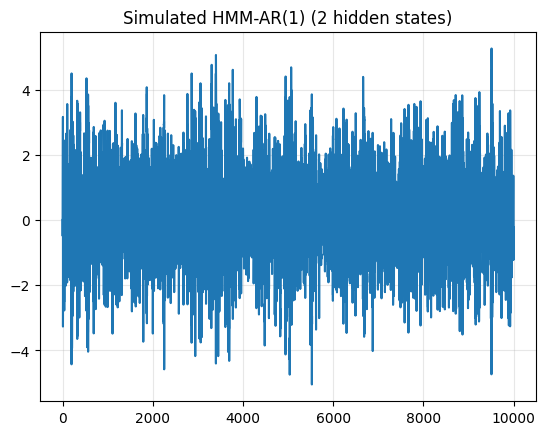

          n    S_prev    S_curr        loglik        p0        p1    gamma0  \
9995   9996  1.356644  1.151695 -13805.947906  0.737173  0.262827  0.051782   
9996   9997  1.151695 -0.170543 -13807.556963  0.603971  0.396029  0.051782   
9997   9998 -0.170543 -1.229291 -13809.696050  0.674959  0.325041  0.051782   
9998   9999 -1.229291 -0.370957 -13810.935291  0.721763  0.278237  0.051782   
9999  10000 -0.370957 -0.222291 -13811.626642  0.684308  0.315692  0.051908   

        gamma1    alpha0    alpha1      eta0      eta1       P00       P11  
9995  0.169447  0.814072 -0.888558  0.705568  0.757205  0.738680  0.553792  
9996  0.169447  0.814072 -0.888558  0.705568  0.757205  0.738680  0.553792  
9997  0.169447  0.814072 -0.888558  0.705568  0.757205  0.738680  0.553792  
9998  0.169447  0.814072 -0.888558  0.705568  0.757205  0.738680  0.553792  
9999  0.169416  0.813979 -0.888460  0.705442  0.757270  0.738862  0.553690  
Transition matrix P:
[[0.73886231 0.26113769]
 [0.44631046 0.55

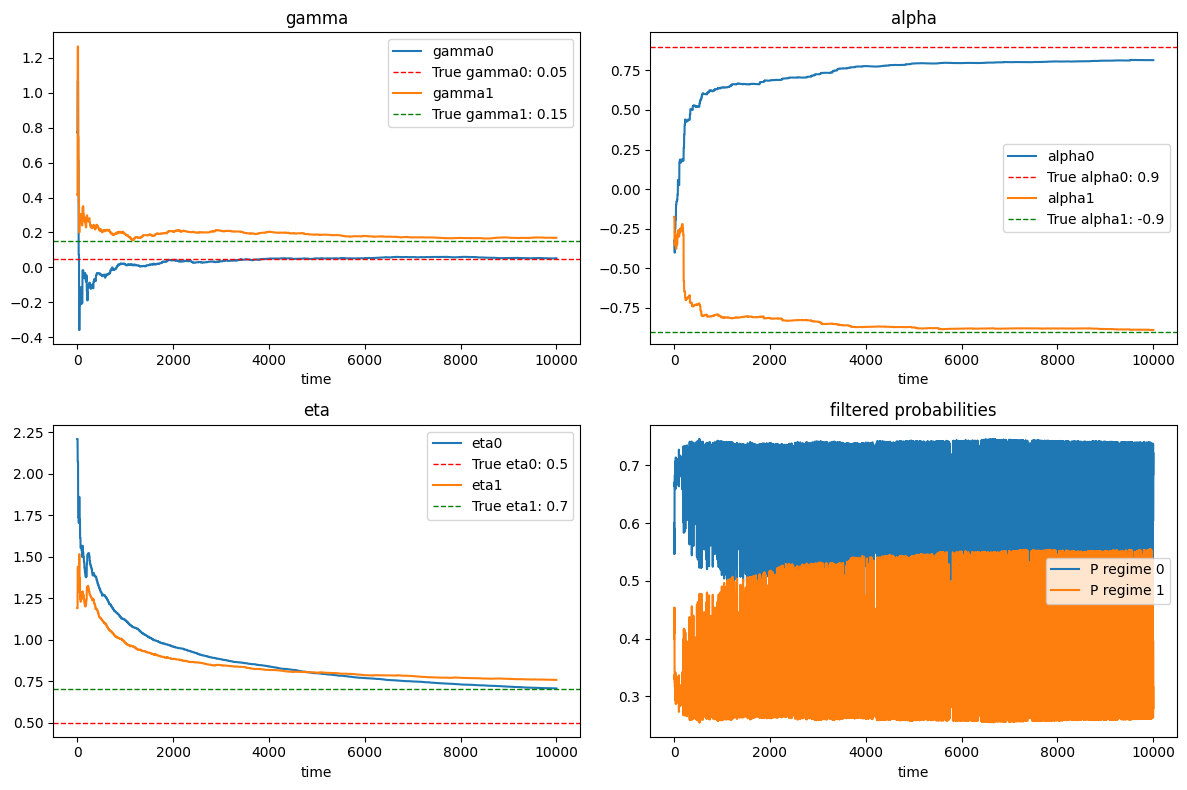

In [5]:
"""
----------------------------------------------------------------------------------------------------------------------
                             Convergence test of the OnlineARHMMEM algorithm 
----------------------------------------------------------------------------------------------------------------------
"""
#simulation of a toy example
gamma00 = 0.05
gamma11 = 0.15

alpha00 = 0.90
alpha11 = -0.90

eta00 = 0.50
eta11 = 0.70

p00 = 0.7
p10 = 0.4

n_step = 10000

state = [0]
S = [0]
for i in range(n_step):
    u = np.random.uniform()
    if state[i] == 0:
        if u <= p00:
            state.append(0)
        else:
            state.append(1)
    else:
        if u <= p10:
            state.append(0)
        else:
            state.append(1)

    z = np.random.normal()
    if state[i + 1] == 0:
        S.append(gamma00 + alpha00 * S[i] + eta00 * z)
    else:
        S.append(gamma11 + alpha11 * S[i] + eta11 * z)

S = np.array(S)

fig, ax = plt.subplots()
ax.plot(S, label = "simulated process")
ax.set_title("Simulated HMM-AR(1) (2 hidden states)")
ax.grid(alpha = .3)
plt.show()


model = OnlineARHMMEM(
    S=S,  
    n_regimes=2,
    batch_size=10,
    init_points=20,
    mstep="paper",  # oppure "ols"
)

hist = model.fit(update_params=True)

print(hist.tail())

pars = model.params()

print("Transition matrix P:")
print(pars["P"])

print("gamma:", pars["gamma"])
print("alpha:", pars["alpha"])
print("eta:", pars["eta"])
print("filtered probs:", pars["filtered_probs"])

mean_next, var_next = model.one_step_forecast()
print("Forecast mean:", mean_next)
print("Forecast variance:", var_next)


same_parametrization = True if abs(gamma00 - pars["gamma"][0]) < abs(gamma00 - pars["gamma"][1]) else False


fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(hist["gamma0"], label="gamma0")
ax[0,0].axhline(gamma00, color='red', linestyle='--', linewidth=1, label=f"True gamma0: {gamma00 if same_parametrization else gamma11}")
ax[0, 0].plot(hist["gamma1"], label="gamma1")
ax[0,0].axhline(gamma11, color='green', linestyle='--', linewidth=1, label=f"True gamma1: {gamma11 if same_parametrization else gamma00}")
ax[0, 0].legend()
ax[0,0].set_xlabel("time")
ax[0, 0].set_title("gamma")

ax[0, 1].plot(hist["alpha0"], label="alpha0")
ax[0,1].axhline(alpha00, color='red', linestyle='--', linewidth=1, label=f"True alpha0: {alpha00 if same_parametrization else alpha11}")
ax[0, 1].plot(hist["alpha1"], label="alpha1")
ax[0,1].axhline(alpha11, color='green', linestyle='--', linewidth=1, label=f"True alpha1: {alpha11 if same_parametrization else alpha00}")
ax[0, 1].legend()
ax[0,1].set_xlabel("time")
ax[0, 1].set_title("alpha")

ax[1, 0].plot(hist["eta0"], label="eta0")
ax[1,0].axhline(eta00, color='red', linestyle='--', linewidth=1, label=f"True eta0: {eta00 if same_parametrization else eta11}")
ax[1, 0].plot(hist["eta1"], label="eta1")
ax[1,0].axhline(eta11, color='green', linestyle='--', linewidth=1, label=f"True eta1: {eta11 if same_parametrization else eta00}")
ax[1, 0].legend()
ax[1,0].set_xlabel("time")
ax[1, 0].set_title("eta")

ax[1, 1].plot(hist["p0"], label="P regime 0")
ax[1, 1].plot(hist["p1"], label="P regime 1")
ax[1, 1].legend()
ax[1,1].set_xlabel("time")
ax[1, 1].set_title("filtered probabilities")

plt.tight_layout()
plt.show(block=True)

